# XGBoost Modeling

## 1. 라이브러리 로드
모델 학습, 평가 및 데이터 처리를 위한 라이브러리를 불러온다.m

In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    average_precision_score
)

from xgboost import XGBClassifier

## 2. 데이터 불러오기

In [62]:
PROJECT_ROOT = '../../'

csv_path = os.path.join(
    PROJECT_ROOT,
    '00_data',
    '01_interim',
    'netflix_users_train.csv'
)

data_df = pd.read_csv(csv_path, low_memory=False)

print(data_df.shape)
data_df.head()

(8621, 18)


,user_id,age,plan_tier,is_active,monthly_spend,age_group,subscription_tenure_days,watch_count,unique_movies,total_watch_time,avg_watch_time,watch_days,recent_watch_count,days_since_last_watch,avg_progress,completion_rate,download_ratio,avg_rating
0,user_01621,55.0,1,1,11.17,5,527,20,19,859.5,42.975000,19,3.0,9,43.225000,0.100000,0.300000,3.714286
1,user_04521,40.0,1,0,7.13,4,695,7,7,528.0,75.428571,6,0.0,126,40.971429,0.000000,0.000000,0.000000
2,user_07927,64.0,2,1,35.39,6,378,14,14,660.1,47.150000,14,0.0,49,47.692857,0.071429,0.142857,3.000000
3,user_01217,52.0,3,1,7.62,5,319,12,12,832.7,69.391667,12,0.0,68,29.491667,0.083333,0.166667,3.000000
4,user_07125,33.0,1,0,60.98,3,510,13,12,709.6,54.584615,12,1.0,8,37.546154,0.153846,0.153846,3.000000


## 3. 데이터 전처리
식별자 제거 및 churn target 생성

In [63]:
final_df = data_df.copy()

# user_id 제거
if 'user_id' in final_df.columns:
    final_df = final_df.drop(columns=['user_id'])

# churn 변수 생성
final_df['is_churned'] = 1 - final_df['is_active']

# 기존 변수 제거
final_df = final_df.drop(columns=['is_active'])

final_df.head()

,age,plan_tier,monthly_spend,age_group,subscription_tenure_days,watch_count,unique_movies,total_watch_time,avg_watch_time,watch_days,recent_watch_count,days_since_last_watch,avg_progress,completion_rate,download_ratio,avg_rating,is_churned
0,55.0,1,11.17,5,527,20,19,859.5,42.975000,19,3.0,9,43.225000,0.100000,0.300000,3.714286,0
1,40.0,1,7.13,4,695,7,7,528.0,75.428571,6,0.0,126,40.971429,0.000000,0.000000,0.000000,1
2,64.0,2,35.39,6,378,14,14,660.1,47.150000,14,0.0,49,47.692857,0.071429,0.142857,3.000000,0
3,52.0,3,7.62,5,319,12,12,832.7,69.391667,12,0.0,68,29.491667,0.083333,0.166667,3.000000,0
4,33.0,1,60.98,3,510,13,12,709.6,54.584615,12,1.0,8,37.546154,0.153846,0.153846,3.000000,1


## 4. Feature / Target 분리

In [64]:
X = final_df.drop(columns=['is_churned'])
y = final_df['is_churned']

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

Feature shape: (8621, 16)
Target distribution:
is_churned
1    0.62081
0    0.37919
Name: proportion, dtype: float64


## 5. Train / Test Split
모델 평가를 위해 데이터를 학습 데이터와 테스트 데이터로 분할한다.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (6896, 16)
Test: (1725, 16)


## 5. 클래스 불균형 비율 계산
XGBoost의 scale_pos_weight에 사용할 값을 계산한다.

In [66]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 0.6108385891146928


## 6. Baseline XGBoost 모델 정의

In [67]:
model = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    scale_pos_weight=scale_pos_weight
)

## 7. CV 설정

In [68]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

## 8. Cross Validation 수행

In [69]:
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("CV Recall:", cv_results['test_recall'].mean())
print("CV F1-score:", cv_results['test_f1'].mean())
print("CV ROC-AUC:", cv_results['test_roc_auc'].mean())
print("CV PR-AUC:", cv_results['test_pr_auc'].mean())

CV Recall: 0.871527497573583
CV F1-score: 0.8770612754081423
CV ROC-AUC: 0.908110124649862
CV PR-AUC: 0.9312003605815301


## 9. Baseline 모델 학습

In [70]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 10. 테스트 예측

In [71]:
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]

## 11. Baseline 모델 평가

In [72]:
print("\nClassification Report")
print(classification_report(y_test, pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred))

print("Recall:", recall_score(y_test, pred))
print("F1-score:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
print("PR-AUC:", average_precision_score(y_test, pred_proba))


Classification Report
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       654
           1       0.88      0.87      0.88      1071

    accuracy                           0.85      1725
   macro avg       0.84      0.84      0.84      1725
weighted avg       0.85      0.85      0.85      1725

Confusion Matrix
[[529 125]
 [140 931]]
Recall: 0.869281045751634
F1-score: 0.8754113775270334
ROC-AUC: 0.9164253876882047
PR-AUC: 0.9436375960522995


## 12. Precision-Recall Curve

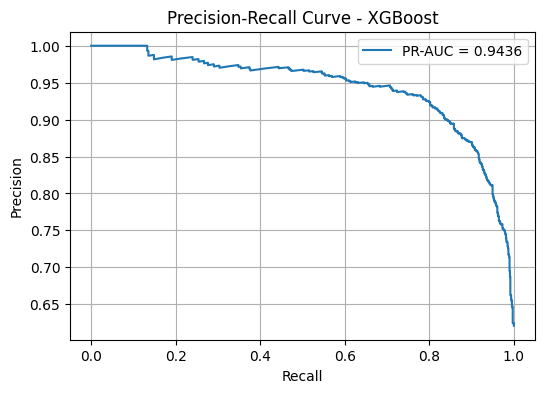

In [73]:
precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

# Hyperparameter Optimization

## 13. Hyperparameter Search 범위 설정
Recall 중심으로 주요 파라미터를 튜닝한다.

In [74]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 3, 5, 10],
    'scale_pos_weight': [scale_pos_weight]
}

## 14. RandomizedSearchCV 실행

In [75]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV Recall:", random_search.best_score_)

best_model = random_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'subsample': 0.7, 'scale_pos_weight': np.float64(0.6108385891146928), 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.9}
Best CV Recall: 0.8733963838209796


## 15. Tuned 모델 예측

In [76]:
pred = best_model.predict(X_test)
pred_proba = best_model.predict_proba(X_test)[:, 1]

## 16. Tuned 모델 평가

In [77]:
print("\nTuned Model Evaluation")
print(classification_report(y_test, pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred))

print("Recall:", recall_score(y_test, pred))
print("F1-score:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
print("PR-AUC:", average_precision_score(y_test, pred_proba))


Tuned Model Evaluation
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       654
           1       0.89      0.88      0.89      1071

    accuracy                           0.86      1725
   macro avg       0.85      0.85      0.85      1725
weighted avg       0.86      0.86      0.86      1725

Confusion Matrix
[[542 112]
 [128 943]]
Recall: 0.880485527544351
F1-score: 0.8871119473189087
ROC-AUC: 0.9223331534448641
PR-AUC: 0.945177792832634


## 17. Tuned PR Curve

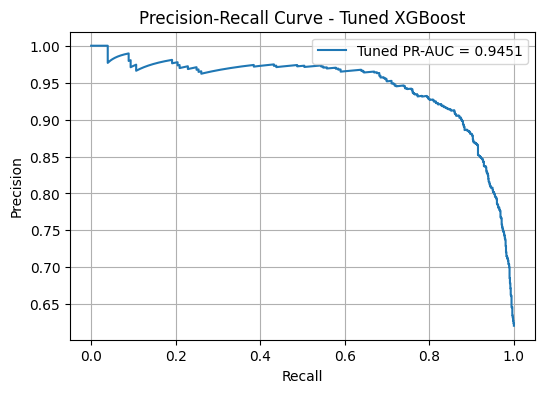

In [78]:
precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'Tuned PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Tuned XGBoost')
plt.legend()
plt.grid(True)
plt.show()

# Threshold Tuning

## 18. Threshold 성능 비교
0.90부터 0.00까지 threshold를 변경하면서 Precision, Recall, F1-score를 비교한다.

In [79]:
threshold_list = np.arange(0.9, -0.01, -0.05)

threshold_result = []

for threshold in threshold_list:
    pred_threshold = (pred_proba >= threshold).astype(int)

    threshold_result.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold),
        "f1": f1_score(y_test, pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_result)
threshold_df

,threshold,precision,recall,f1
0,9.000000e-01,0.967841,0.590103,0.733179
1,8.500000e-01,0.957031,0.686275,0.799347
2,8.000000e-01,0.945652,0.731092,0.824645
3,7.500000e-01,0.933941,0.765640,0.841457
4,7.000000e-01,0.931868,0.791783,0.856133
5,6.500000e-01,0.924628,0.813259,0.865375
6,6.000000e-01,0.917178,0.837535,0.875549
7,5.500000e-01,0.907662,0.862745,0.884634
8,5.000000e-01,0.893839,0.880486,0.887112
9,4.500000e-01,0.885079,0.891690,0.888372


## 19. Threshold 성능 시각화

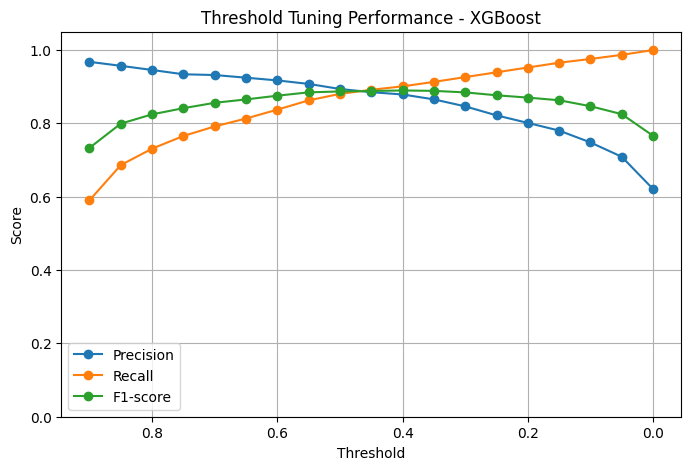

In [80]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['f1'],
    marker='o',
    label='F1-score'
)

plt.gca().invert_xaxis()
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning Performance - XGBoost')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

## 20. Precision-Recall Trade-off 시각화

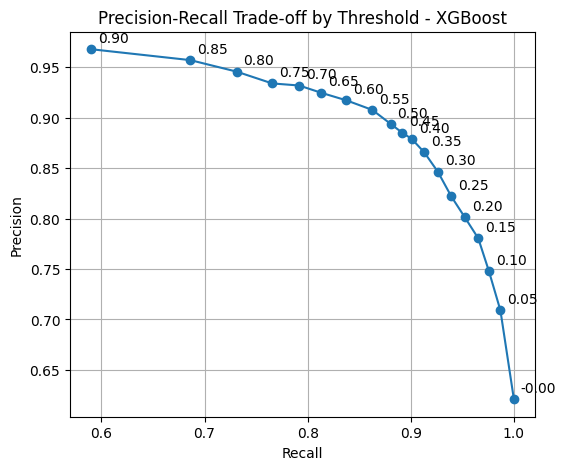

In [81]:
plt.figure(figsize=(6, 5))

plt.plot(
    threshold_df['recall'],
    threshold_df['precision'],
    marker='o'
)

for _, row in threshold_df.iterrows():
    plt.annotate(
        f"{row['threshold']:.2f}",
        (row['recall'], row['precision']),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off by Threshold - XGBoost')
plt.grid(True)
plt.show()

## 21. 최종 Threshold 적용
시각화와 성능표를 바탕으로 threshold를 선택하여 최종 성능을 확인한다.

In [82]:
best_threshold = 0.80

pred_final = (pred_proba >= best_threshold).astype(int)

print(classification_report(y_test, pred_final))
print(confusion_matrix(y_test, pred_final))

print("Precision:", precision_score(y_test, pred_final, zero_division=0))
print("Recall:", recall_score(y_test, pred_final))
print("F1-score:", f1_score(y_test, pred_final))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
print("PR-AUC:", average_precision_score(y_test, pred_proba))

              precision    recall  f1-score   support

           0       0.68      0.93      0.79       654
           1       0.95      0.73      0.82      1071

    accuracy                           0.81      1725
   macro avg       0.81      0.83      0.80      1725
weighted avg       0.84      0.81      0.81      1725

[[609  45]
 [288 783]]
Precision: 0.9456521739130435
Recall: 0.7310924369747899
F1-score: 0.8246445497630331
ROC-AUC: 0.9223331534448641
PR-AUC: 0.945177792832634


# Feature Importance

## 22. Feature Importance 추출

In [83]:
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
7,total_watch_time,0.187781
9,watch_days,0.112541
0,age,0.090955
3,age_group,0.082496
1,plan_tier,0.078382
12,avg_progress,0.063841
11,days_since_last_watch,0.047630
13,completion_rate,0.044413
6,unique_movies,0.044320
5,watch_count,0.041718


## 23. Feature Importance 시각화

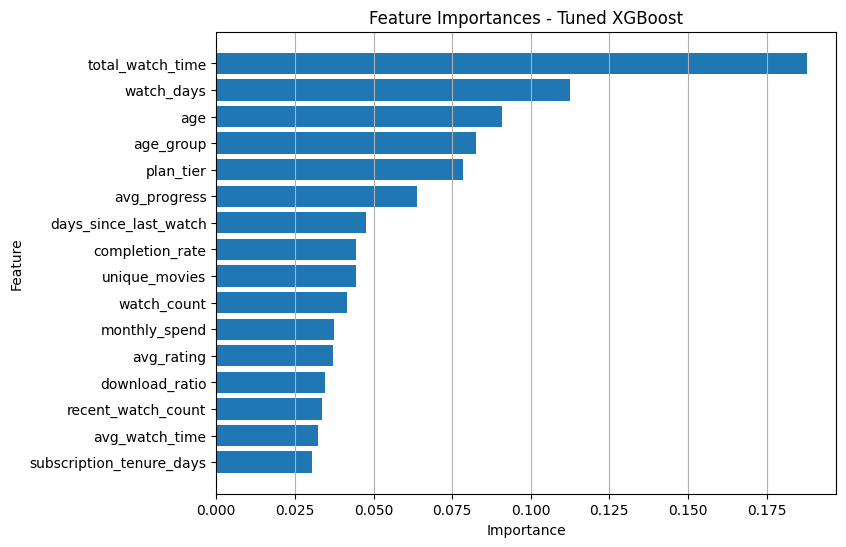

In [86]:
plt.figure(figsize=(8, 6))

plot_df = feature_importance_df.sort_values(by='importance', ascending=True)

plt.barh(plot_df['feature'], plot_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances - Tuned XGBoost')
plt.grid(axis='x')
plt.show()